For this example we use Default of Credit Card Clients.

https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.

# Environment


For this project, you can create a Python environment either with **`.venv`** or with **Conda**.

## Option 1: Create an environment with `.venv`

```bash
python -m venv .venv

.venv/bin/activate
```

## Option 2: Create an environment with Conda

You can create a Conda environment either from the command line or with Anaconda Navigator.

Using the command line


```bash
conda create -n my-env
conda activate my-env

```

Alternatively you cane use the Anaconda Navigator

Im .venv-Ordner installieren:

pip install ucimlrepo

# Import

In [4]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt 
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


# Data Loading

In [5]:
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables)

ConnectionError: Error connecting to server

# Data Insights

In [ ]:
X.info()
print("---------------------------------------")
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
dtypes: int64(23)
memory us

In [ ]:
X.describe()
#y.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


Y
0    23364
1     6636
Name: count, dtype: int64
Y
0    0.7788
1    0.2212
Name: proportion, dtype: float64


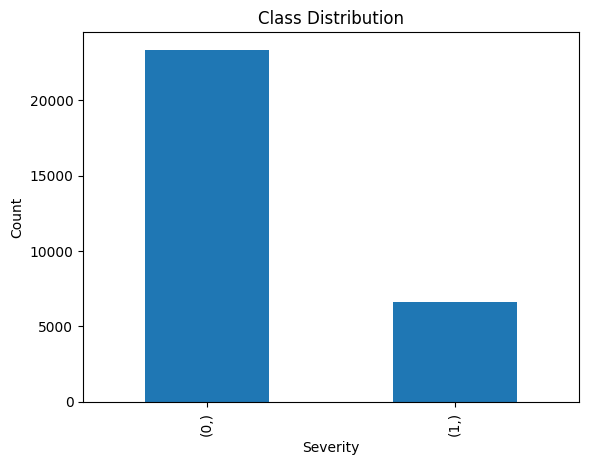

In [ ]:
# y => Zahlungsverzug yes (1) , or no (0)
print(y.value_counts())
print(y.value_counts(normalize=True))

y.value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

--> no missing values

--> all numerical, no categorical data

--> imbalanced dataset

# Target Encoding

In [ ]:
y

,Y
0,1
1,1
2,0
3,0
4,0
...,...
29995,0
29996,0
29997,1
29998,1


# Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("y value counts normalized: \n", y.value_counts(normalize=True))
print("---------------------------------------")
print("y_train value counts normalized: \n", y_train.value_counts(normalize=True))
print("---------------------------------------")
print("---------------------------------------")
print("y_test value counts normalized: \n", y_test.value_counts(normalize=True))

NameError: name 'X' is not defined

# Outlier Handling

# Scaling

# Over- and Undersampling

# Modelling

We use the models we learned in lecture.

## Logistic Regression

## k-NN

## SVM

## Random Forest

## XGBoost

# Testing

## Logistig Regression

## K-NN

## SVM

## Random Forest

## XGBoost